In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from setup import train, device, train_test_split_path, train_test, accuracy
X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()

Usando dispositivo: cuda


In [3]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.pairs = list(zip(X, y))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        xs, ys = self.pairs[idx]

        return {
            'input': torch.tensor(xs).to(device=device, dtype=torch.float32),
            'target': F.one_hot(torch.tensor(ys), 10).to(device=device, dtype=torch.float32),
            'input_length': xs.shape,
            'target_length': 10
        }

In [7]:
MAX_LEN = 660000
SR = 22050
HOP_LENGTH = int(SR * 0.01)  # 10 ms hop length
WIN_LENGTH = int(SR * 0.025)  # 30 ms window length

X_train, X_test = train_test(X_train_path, X_test_path, espectrogram_name = 'mel', sr=SR, max_len=MAX_LEN, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = dataset(X_train, y_train)
test_dataset = dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-24.3248, -21.0954, -23.4452,  ..., -30.2619, -23.5789, -27.8883],
         [-22.1997, -15.9695, -17.6158,  ..., -30.6667, -25.0086, -25.3555],
         [-22.0932, -18.1459, -19.9255,  ..., -28.9762, -28.1742, -27.1611],
         ...,
         [-44.0200, -39.7173, -41.0933,  ..., -38.3236, -35.2173, -39.8389],
         [-41.5486, -39.7546, -35.8413,  ..., -41.4476, -38.6974, -41.5935],
         [-40.6956, -36.3746, -36.3715,  ..., -40.2328, -41.2249, -43.5400]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (80, 3001),
 'target_length': 10}

### Simple CNN

In [26]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        # (B,1 ,80,3001) → Conv → LeakyReLU → Pool → (B,32,40,1500)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        # (B,32,40,1500) → Conv → LeakyReLU → Pool → (B,64,20,750)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        # (B,64,20,750) → Conv → LeakyReLU → Pool → (B,128,10,375)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        # Global pooling to collapse spatial dims → (B,128,1,1)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc       = nn.Linear(128, 10)

    def forward(self, x):
        x = x.unsqueeze(1) # add channel dimension for Conv2d (B,80,3001) -> (B,1,80,3001)

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = self.global_pool(x)
        
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x


Con mel

In [27]:
# Definimos hiperparámetros
NUM_EPOCHS = 50
LEARNING_RATE = 0.001

# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 93962 parámetros


In [28]:
#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 1.5447
  Pérdida Validación: 1.5117
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 1.3424
  Pérdida Validación: 1.2649
  Mejorando
Época 15/50
  Pérdida Entrenamiento: 1.1775
  Pérdida Validación: 1.1564
  Mejorando
Época 20/50
  Pérdida Entrenamiento: 1.0520
  Pérdida Validación: 0.9820
  Mejorando
Época 25/50
  Pérdida Entrenamiento: 0.9416
  Pérdida Validación: 0.9030
  Mejorando
Época 30/50
  Pérdida Entrenamiento: 0.8541
  Pérdida Validación: 0.8813
  Mejorando
Época 35/50
  Pérdida Entrenamiento: 0.7701
  Pérdida Validación: 0.8170
  Empeorando
Época 40/50
  Pérdida Entrenamiento: 0.7124
  Pérdida Validación: 0.8757
  Empeorando
Época 45/50
  Pérdida Entrenamiento: 0.6412
  Pérdida Validación: 0.8332
  Empeorando
Época 50/50
  Pérdida Entrenamiento: 0.5976
  Pérdida Validación: 0.8543
  Empeorando
Entrenamiento completado! Tiempo total: 326.69 segundos
-------------

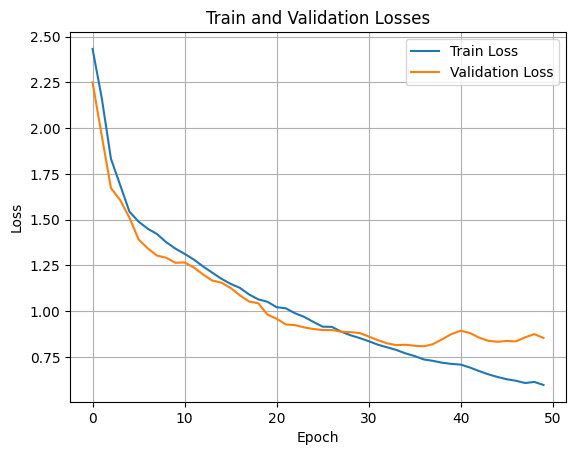

In [29]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.grid(True)
#plt.yscale('log')
plt.show()

Mfcc

In [30]:
MAX_LEN = 660000
SR = 22050
HOP_LENGTH = int(SR * 0.01)  # 10 ms hop length
WIN_LENGTH = int(SR * 0.025)  # 30 ms window length

X_train, X_test = train_test(X_train_path, X_test_path, espectrogram_name = 'mfcc', sr=SR, max_len=MAX_LEN, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = dataset(X_train, y_train)
test_dataset = dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[ 0.4008,  2.0022,  0.7769,  ..., -0.6358, -0.7985, -1.2709],
         [-0.1132, -0.6555, -0.1558,  ..., -0.5243, -0.3029, -1.2071],
         [ 0.1937, -0.5440,  0.7011,  ...,  0.8279,  0.8248,  0.3340],
         ...,
         [-0.0959, -0.0959, -0.0959,  ...,  0.7572,  0.7572,  0.7572],
         [-0.1486, -0.1486, -0.1486,  ...,  0.9286,  0.9286,  0.9286],
         [-0.5563, -0.5563, -0.5563,  ..., -0.0409, -0.0409, -0.0409]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (60, 1288),
 'target_length': 10}

In [31]:
# Definimos hiperparámetros
NUM_EPOCHS = 50
LEARNING_RATE = 0.001

# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 93962 parámetros


In [32]:
#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 2.0863
  Pérdida Validación: 1.9959
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 1.8994
  Pérdida Validación: 1.9435
  Empeorando
Época 15/50
  Pérdida Entrenamiento: 1.7188
  Pérdida Validación: 1.8053
  Mejorando
Época 20/50
  Pérdida Entrenamiento: 1.5883
  Pérdida Validación: 1.6655
  Mejorando
Época 25/50
  Pérdida Entrenamiento: 1.4697
  Pérdida Validación: 1.5474
  Mejorando
Época 30/50
  Pérdida Entrenamiento: 1.3650
  Pérdida Validación: 1.4715
  Mejorando
Época 35/50
  Pérdida Entrenamiento: 1.2801
  Pérdida Validación: 1.4031
  Mejorando
Época 40/50
  Pérdida Entrenamiento: 1.2129
  Pérdida Validación: 1.3848
  Empeorando
Época 45/50
  Pérdida Entrenamiento: 1.1438
  Pérdida Validación: 1.3862
  Empeorando
Época 50/50
  Pérdida Entrenamiento: 1.0749
  Pérdida Validación: 1.3266
  Mejorando
Entrenamiento completado! Tiempo total: 100.51 segundos
--------------

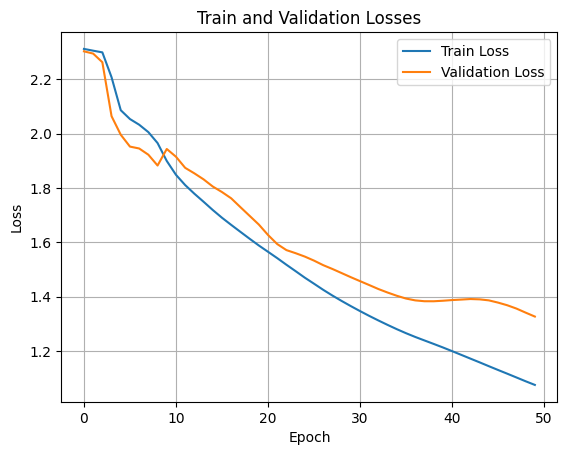

In [33]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.grid(True)
#plt.yscale('log')
plt.show()

Probar mas epocas!

CTq

In [34]:
MAX_LEN = 660000
SR = 22050
HOP_LENGTH = int(SR * 0.01)  # 10 ms hop length
WIN_LENGTH = int(SR * 0.025)  # 30 ms window length

X_train, X_test = train_test(X_train_path, X_test_path, espectrogram_name = 'cqt', sr=SR, max_len=MAX_LEN, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = dataset(X_train, y_train)
test_dataset = dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-31.1200, -30.9381, -31.0292,  ..., -41.3613, -39.6287, -38.5573],
         [-30.0745, -29.4315, -29.0274,  ..., -32.1641, -32.5271, -33.3078],
         [-33.6152, -32.0733, -31.1597,  ..., -34.5098, -33.3413, -32.3286],
         ...,
         [-36.0252, -36.3203, -43.3733,  ..., -35.3288, -41.8223, -42.4720],
         [-37.7138, -41.6761, -40.3232,  ..., -48.3111, -48.3366, -40.7222],
         [-40.7524, -43.9236, -38.7732,  ..., -47.9594, -52.0674, -50.3824]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (84, 1290),
 'target_length': 10}

In [35]:
# Definimos hiperparámetros
NUM_EPOCHS = 50
LEARNING_RATE = 0.001

# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

Modelo creado con 93962 parámetros


In [36]:
#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses, val_losses = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Iniciando entrenamiento...
--------------------------------------------------
Época 5/50
  Pérdida Entrenamiento: 1.8352
  Pérdida Validación: 1.7843
  Mejorando
Época 10/50
  Pérdida Entrenamiento: 1.5720
  Pérdida Validación: 1.5049
  Mejorando
Época 15/50
  Pérdida Entrenamiento: 1.4148
  Pérdida Validación: 1.4542
  Empeorando
Época 20/50
  Pérdida Entrenamiento: 1.2587
  Pérdida Validación: 1.3164
  Mejorando
Época 25/50
  Pérdida Entrenamiento: 1.1323
  Pérdida Validación: 1.2115
  Empeorando
Época 30/50
  Pérdida Entrenamiento: 1.0339
  Pérdida Validación: 1.2120
  Empeorando
Época 35/50
  Pérdida Entrenamiento: 0.9266
  Pérdida Validación: 1.2288
  Empeorando
Época 40/50
  Pérdida Entrenamiento: 0.8361
  Pérdida Validación: 1.2417
  Empeorando
Época 45/50
  Pérdida Entrenamiento: 0.7960
  Pérdida Validación: 1.3289
  Empeorando
Época 50/50
  Pérdida Entrenamiento: 0.7669
  Pérdida Validación: 1.2580
  Empeorando
Entrenamiento completado! Tiempo total: 144.48 segundos
----------

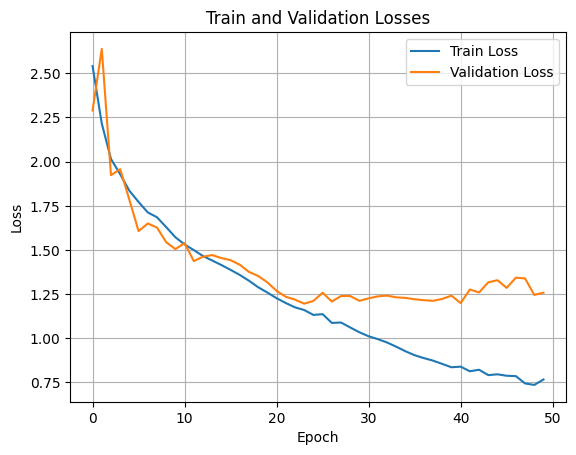

In [37]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.grid(True)
#plt.yscale('log')
plt.show()

In [ ]:
torch.save(model.state_dict(), 'modelol_cnns1.pth')